# Load Example Images

In [1]:
import requests
from PIL import Image
from io import BytesIO
import os

# Output folder
output_folder = "/kaggle/working/"
os.makedirs(output_folder, exist_ok=True)

# Number of images
n = 9

for i in range(1, n + 1):
    url = "https://picsum.photos/300"

    res = requests.get(url)
    img = Image.open(BytesIO(res.content)).convert("RGB")

    save_path = os.path.join(output_folder, f"img{i}.jpg")
    img.save(save_path, "JPEG")

print("Saved 9 images from API to /kaggle/working/")

Saved 9 images from API to /kaggle/working/


# Main Code (Rafat's Area for Greyscale Color Palette)

## Grayscale Quantization Formula (Color Palette Reduction)

### Formula

$$
\text{new\_pixel} = \left\lfloor \frac{\text{pixel}}{256 / N} \right\rfloor \times \left(\frac{256}{N}\right)
$$

### Where

- **pixel**: Original pixel value (0–255)  
- **N**: Palette size (number of gray levels)  

---

### Example

For $N = 4$:

$$
\text{step} = \frac{256}{4} = 64
$$

Output values:
$$
0,\ 64,\ 128,\ 192
$$

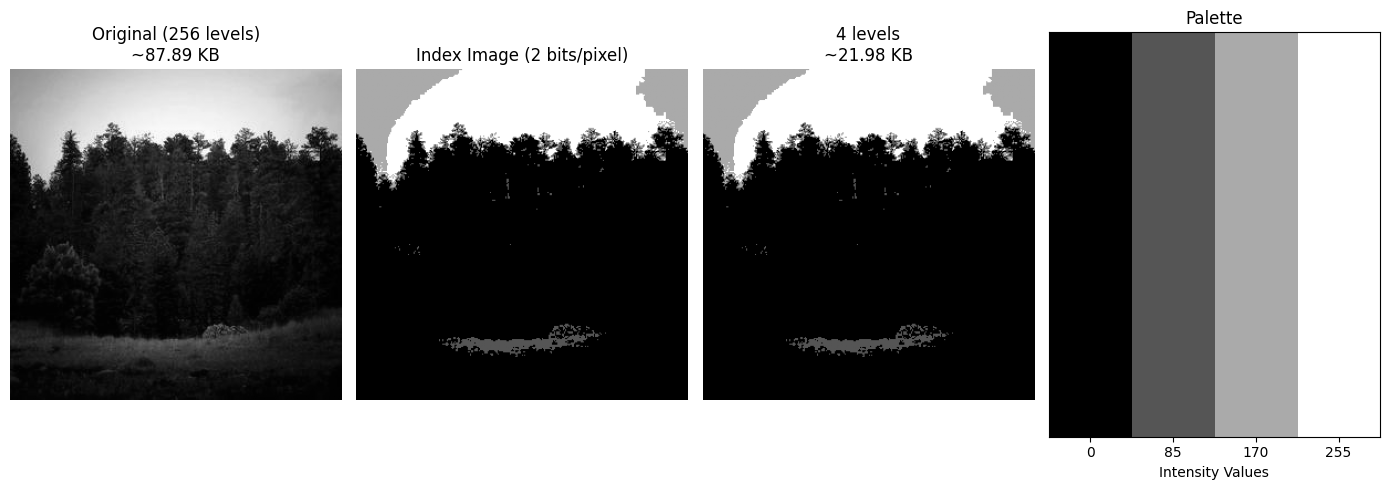

Palette values: [  0  85 170 255]
Bits per pixel (index): 2
Original Size: 87.89 KB
Quantized Size (Index + Palette): 21.98 KB
Compression: 75.00% reduction


In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ===== INPUT =====
palette_size = 4

# Load image and convert to grayscale
img = Image.open('img1.jpg').convert('L')
img_np = np.array(img)

# Validate palette size
if palette_size <= 0 or palette_size > 256:
    raise ValueError("Palette size must be between 1 and 256")

# ===== CREATE PALETTE =====
palette = np.linspace(0, 255, palette_size, dtype=np.uint8)

# ===== CREATE INDEX IMAGE =====
step = 256 // palette_size
index_img = img_np // step
index_img = np.clip(index_img, 0, palette_size - 1)

# Reconstruct image
quantized_np = palette[index_img]

# ===== SIZE ESTIMATION =====
h, w = img_np.shape
original_size_kb = (h * w * 8) / (8 * 1024)

bits_per_pixel = int(np.ceil(np.log2(palette_size)))
index_size = (h * w * bits_per_pixel) / (8 * 1024)
palette_size_kb = (palette_size * 8) / (8 * 1024)

quantized_size_kb = index_size + palette_size_kb

# ===== CREATE PALETTE IMAGE FOR DISPLAY =====
palette_img = np.tile(palette, (50, 1))  # height=50 for visibility

# ===== DISPLAY =====
plt.figure(figsize=(14,5))

# Original
plt.subplot(1,4,1)
plt.imshow(img_np, cmap='gray')
plt.title(f"Original (256 levels)\n~{original_size_kb:.2f} KB")
plt.axis('off')

# Index Image
plt.subplot(1,4,2)
plt.imshow(index_img, cmap='gray')
plt.title(f"Index Image ({bits_per_pixel} bits/pixel)")
plt.axis('off')

# Quantized Image
plt.subplot(1,4,3)
plt.imshow(quantized_np, cmap='gray')
plt.title(f"{palette_size} levels\n~{quantized_size_kb:.2f} KB")
plt.axis('off')

# Palette Visualization
plt.subplot(1,4,4)
plt.imshow(palette_img, cmap='gray', aspect='auto')
plt.title("Palette")
plt.xticks(range(palette_size), palette)
plt.yticks([])
plt.xlabel("Intensity Values")

plt.tight_layout()
plt.show()

# ===== PRINT DETAILS =====
print("Palette values:", palette)
print("Bits per pixel (index):", bits_per_pixel)
print(f"Original Size: {original_size_kb:.2f} KB")
print(f"Quantized Size (Index + Palette): {quantized_size_kb:.2f} KB")
print(f"Compression: {(1 - quantized_size_kb/original_size_kb)*100:.2f}% reduction")

# Main Code (Pravesh's Area)

# Main Code (Rafat's Area for RGB Color Palette)

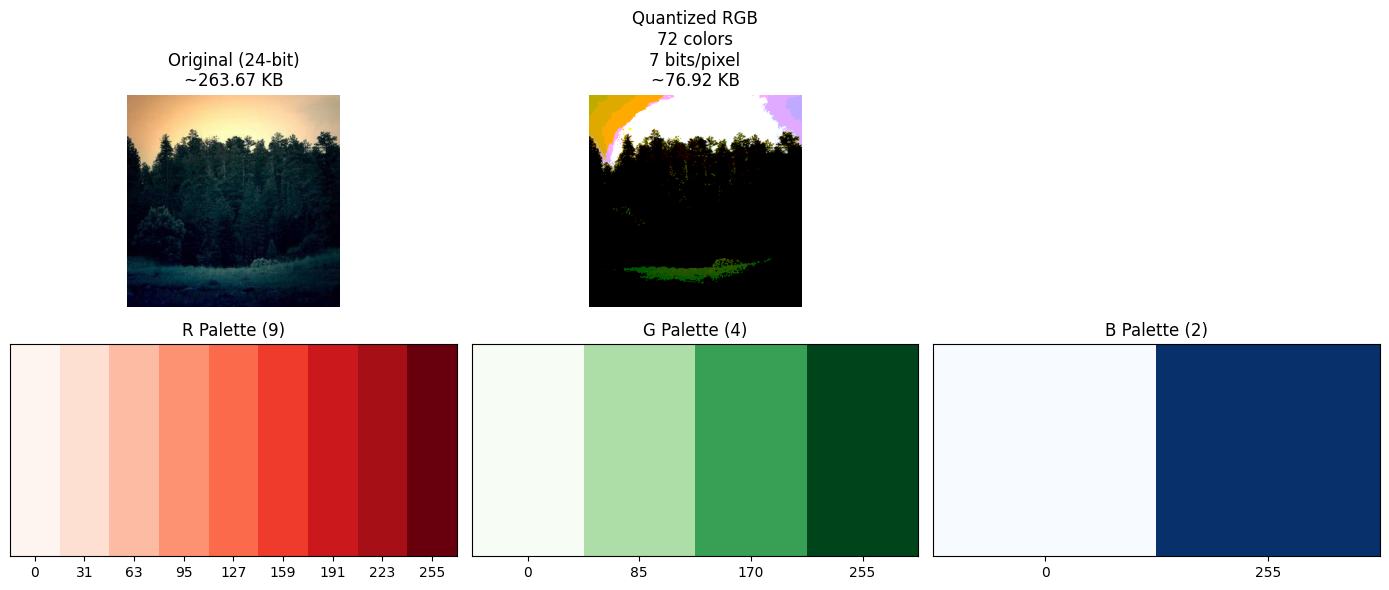

R Palette: [  0  31  63  95 127 159 191 223 255]
G Palette: [  0  85 170 255]
B Palette: [  0 255]
Bits per pixel: 7
Original Size: 263.67 KB
Quantized Size: 76.92 KB
Compression: 70.83% reduction


In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ===== INPUT =====
R_levels = 9
G_levels = 4
B_levels = 2

# Load image
img = Image.open('img1.jpg').convert('RGB')
img_np = np.array(img)

# Split channels
R = img_np[:, :, 0]
G = img_np[:, :, 1]
B = img_np[:, :, 2]

# ===== CREATE PALETTES =====
palette_R = np.linspace(0, 255, R_levels, dtype=np.uint8)
palette_G = np.linspace(0, 255, G_levels, dtype=np.uint8)
palette_B = np.linspace(0, 255, B_levels, dtype=np.uint8)

# ===== CREATE INDEX IMAGES =====
step_R = 256 // R_levels
step_G = 256 // G_levels
step_B = 256 // B_levels

R_idx = np.clip(R // step_R, 0, R_levels - 1)
G_idx = np.clip(G // step_G, 0, G_levels - 1)
B_idx = np.clip(B // step_B, 0, B_levels - 1)

# ===== RECONSTRUCT IMAGE =====
R_q = palette_R[R_idx]
G_q = palette_G[G_idx]
B_q = palette_B[B_idx]

quantized_np = np.stack([R_q, G_q, B_q], axis=2)

# ===== SIZE ESTIMATION =====
h, w, _ = img_np.shape

# Original (24-bit)
original_size_kb = (h * w * 24) / (8 * 1024)

# Bits per channel (must be integer)
bits_R = int(np.ceil(np.log2(R_levels)))
bits_G = int(np.ceil(np.log2(G_levels)))
bits_B = int(np.ceil(np.log2(B_levels)))

bits_per_pixel = bits_R + bits_G + bits_B

# Index image size
index_size = (h * w * bits_per_pixel) / (8 * 1024)

# Palette storage (each color = 8 bits per channel)
palette_size_kb = ((R_levels + G_levels + B_levels) * 8) / (8 * 1024)

quantized_size_kb = index_size + palette_size_kb

# Total colors
total_colors = R_levels * G_levels * B_levels

# ===== CREATE PALETTE VISUALS =====
palette_R_img = np.tile(palette_R, (40, 1))
palette_G_img = np.tile(palette_G, (40, 1))
palette_B_img = np.tile(palette_B, (40, 1))

# ===== DISPLAY =====
plt.figure(figsize=(14,6))

# Original
plt.subplot(2,3,1)
plt.imshow(img_np)
plt.title(f"Original (24-bit)\n~{original_size_kb:.2f} KB")
plt.axis('off')

# Quantized
plt.subplot(2,3,2)
plt.imshow(quantized_np)
plt.title(f"Quantized RGB\n{total_colors} colors\n{bits_per_pixel} bits/pixel\n~{quantized_size_kb:.2f} KB")
plt.axis('off')

# R palette
plt.subplot(2,3,4)
plt.imshow(palette_R_img, cmap='Reds', aspect='auto')
plt.title(f"R Palette ({R_levels})")
plt.xticks(range(R_levels), palette_R)
plt.yticks([])

# G palette
plt.subplot(2,3,5)
plt.imshow(palette_G_img, cmap='Greens', aspect='auto')
plt.title(f"G Palette ({G_levels})")
plt.xticks(range(G_levels), palette_G)
plt.yticks([])

# B palette
plt.subplot(2,3,6)
plt.imshow(palette_B_img, cmap='Blues', aspect='auto')
plt.title(f"B Palette ({B_levels})")
plt.xticks(range(B_levels), palette_B)
plt.yticks([])

plt.tight_layout()
plt.show()

# ===== PRINT DETAILS =====
print("R Palette:", palette_R)
print("G Palette:", palette_G)
print("B Palette:", palette_B)
print("Bits per pixel:", bits_per_pixel)
print(f"Original Size: {original_size_kb:.2f} KB")
print(f"Quantized Size: {quantized_size_kb:.2f} KB")
print(f"Compression: {(1 - quantized_size_kb/original_size_kb)*100:.2f}% reduction")